
# 03 — Modeling Axe 3 (Version 1)

**Projet :** Stroke Prediction AI  
**Notebook 3 :** Modeling pour l’Axe 3 — Mortality Prediction  
**Dataset utilisé :** données preprocessées issues du notebook précédent  
**Environnement ciblé :** Google Colab

---

## Objectif de ce notebook

Ce notebook réalise la **modélisation de l’Axe 3**, c’est-à-dire la prédiction de la mortalité post-AVC selon deux horizons temporels :

- `DDEAD` : mortalité à **14 jours**
- `FDEAD` : mortalité à **6 mois**

Les données utilisées ici proviennent directement du notebook de preprocessing :

- `X_ddead_preprocessed_v1.csv`
- `y_ddead_preprocessed_v1.csv`
- `X_fdead_preprocessed_v1.csv`
- `y_fdead_preprocessed_v1.csv`

---

## Logique de cette Version 1

Dans cette première version, on construit une base de modélisation **simple, lisible et défendable** :

1. chargement des fichiers preprocessés ;
2. séparation train / test ;
3. entraînement de modèles de base ;
4. évaluation avec des métriques adaptées à l’objectif clinique ;
5. comparaison des résultats ;
6. sauvegarde des modèles.

---

## Choix méthodologiques

Pour rester cohérent avec le cahier des charges, on utilise ici des modèles simples et classiques pour une première version :

- **Régression Logistique**
- **Random Forest**

Les métriques mises en avant sont surtout :

- **Recall**
- **AUC-ROC**
- **Classification Report**
- **Confusion Matrix**

Le **Recall** est particulièrement important ici, car en contexte médical il est plus grave de manquer un patient à risque que de produire un faux positif.



## Rappel du cahier des charges

Le cahier des charges indique que l’**Axe 3** concerne la **prédiction de la mortalité à 14 jours (`DDEAD`) et à 6 mois (`FDEAD`)** à partir du dataset IST.  
Il précise également que, pour cet axe, les métriques à privilégier sont notamment **l’AUC-ROC** et surtout le **Recall**, afin de minimiser les faux négatifs.


In [1]:

# =========================
# 1. Imports
# =========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



## Chargement des fichiers preprocessés depuis Google Drive

Ce notebook est conçu pour fonctionner sur **Google Colab**.  
On commence donc par monter Google Drive, puis on charge les fichiers exportés par le notebook de preprocessing.

### Fichiers attendus
- `X_ddead_preprocessed_v1.csv`
- `y_ddead_preprocessed_v1.csv`
- `X_fdead_preprocessed_v1.csv`
- `y_fdead_preprocessed_v1.csv`


In [2]:

# =========================
# 2. Chargement des données preprocessées
# =========================

drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Stroke_Project_ML/Data/"

X_ddead = pd.read_csv(base_path + "X_ddead_preprocessed_v1.csv")
y_ddead = pd.read_csv(base_path + "y_ddead_preprocessed_v1.csv").squeeze()

X_fdead = pd.read_csv(base_path + "X_fdead_preprocessed_v1.csv")
y_fdead = pd.read_csv(base_path + "y_fdead_preprocessed_v1.csv").squeeze()

# Sécurisation du type des cibles
y_ddead = pd.to_numeric(y_ddead, errors="coerce").astype(int)
y_fdead = pd.to_numeric(y_fdead, errors="coerce").astype(int)

print("Chargement terminé.")
print("X_ddead :", X_ddead.shape)
print("y_ddead :", y_ddead.shape)
print("X_fdead :", X_fdead.shape)
print("y_fdead :", y_fdead.shape)


Mounted at /content/drive
Chargement terminé.
X_ddead : (19410, 31)
y_ddead : (19410,)
X_fdead : (19279, 31)
y_fdead : (19279,)



## Vérification rapide des distributions de classes

Avant d’entraîner les modèles, il est important d’observer la distribution des classes pour chaque cible.

Cela permet de :
- vérifier que les cibles sont bien binaires ;
- voir si les classes sont déséquilibrées ;
- justifier l’importance du **Recall** dans l’évaluation.


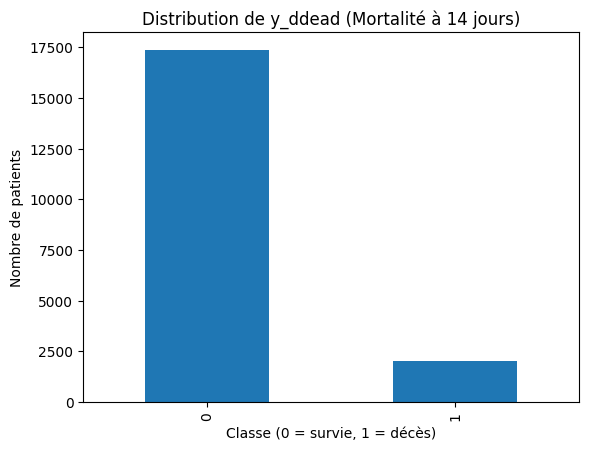

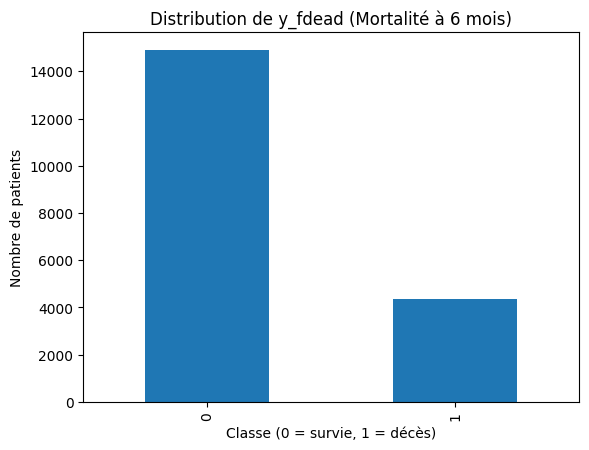

In [4]:

# =========================
# 3. Visualisation des classes
# =========================
# Objectif :
# Visualiser la distribution des classes pour :
# - y_ddead (mortalité à 14 jours)
# - y_fdead (mortalité à 6 mois)
# afin d’identifier un éventuel déséquilibre

import matplotlib.pyplot as plt

# -------------------------
# Distribution de y_ddead
# -------------------------
plt.figure()

y_ddead.value_counts().sort_index().plot(kind='bar')

plt.title("Distribution de y_ddead (Mortalité à 14 jours)")
plt.xlabel("Classe (0 = survie, 1 = décès)")
plt.ylabel("Nombre de patients")

plt.show()


# -------------------------
# Distribution de y_fdead
# -------------------------
plt.figure()

y_fdead.value_counts().sort_index().plot(kind='bar')

plt.title("Distribution de y_fdead (Mortalité à 6 mois)")
plt.xlabel("Classe (0 = survie, 1 = décès)")
plt.ylabel("Nombre de patients")

plt.show()



## Séparation train / test

On sépare les données en :
- **80 % pour l’entraînement**
- **20 % pour le test**

On utilise `stratify=y` afin de préserver la distribution des classes dans les deux sous-ensembles, ce qui est particulièrement important dans un problème médical potentiellement déséquilibré.


In [5]:

# =========================
# 4. Train / Test Split
# =========================

X_train_ddead, X_test_ddead, y_train_ddead, y_test_ddead = train_test_split(
    X_ddead,
    y_ddead,
    test_size=0.2,
    random_state=42,
    stratify=y_ddead
)

X_train_fdead, X_test_fdead, y_train_fdead, y_test_fdead = train_test_split(
    X_fdead,
    y_fdead,
    test_size=0.2,
    random_state=42,
    stratify=y_fdead
)

print("DDEAD - Train :", X_train_ddead.shape, "| Test :", X_test_ddead.shape)
print("FDEAD - Train :", X_train_fdead.shape, "| Test :", X_test_fdead.shape)


DDEAD - Train : (15528, 31) | Test : (3882, 31)
FDEAD - Train : (15423, 31) | Test : (3856, 31)



## Définition des modèles

Dans cette version 1, on utilise deux modèles de base :

### 1. Régression Logistique
C’est un modèle de référence simple, interprétable et souvent pertinent pour une première approche binaire.

### 2. Random Forest
Ce modèle permet de capter des relations non linéaires et sert ici de deuxième baseline plus flexible.

Pour tenir compte du déséquilibre de classes, on active `class_weight="balanced"` dans les deux modèles.


In [6]:

# =========================
# 5. Définition des modèles
# =========================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}



## Fonction d’évaluation

Pour éviter la répétition du code, on crée une fonction qui :

1. entraîne le modèle ;
2. effectue les prédictions ;
3. calcule les principales métriques ;
4. affiche la matrice de confusion ;
5. retourne un résumé des performances.

### Métriques calculées
- Accuracy
- Precision
- Recall
- F1-score
- AUC-ROC


In [7]:

# =========================
# 6. Fonction d'évaluation
# =========================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, target_name):
    # Entraînement du modèle
    model.fit(X_train, y_train)

    # Prédictions de classes
    y_pred = model.predict(X_test)

    # Probabilités pour calculer l'AUC-ROC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    # Calcul des métriques
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    print("=" * 70)
    print(f"Target : {target_name}")
    print(f"Modèle : {model_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"AUC-ROC   : {auc:.4f}")
    print("\nClassification Report :")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matrice de confusion - {model_name} - {target_name}")
    plt.show()

    return {
        "Target": target_name,
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "AUC-ROC": auc
    }



## Entraînement et évaluation sur `DDEAD`

On commence par la première tâche de l’Axe 3 : la prédiction de la **mortalité à 14 jours**.

Chaque modèle est entraîné puis évalué sur le jeu de test.  
L’objectif est d’obtenir une première comparaison simple entre les performances.


Target : DDEAD
Modèle : Logistic Regression
Accuracy  : 0.7411
Precision : 0.2462
Recall    : 0.7125
F1-score  : 0.3659
AUC-ROC   : 0.8018

Classification Report :
              precision    recall  f1-score   support

           0       0.96      0.74      0.84      3475
           1       0.25      0.71      0.37       407

    accuracy                           0.74      3882
   macro avg       0.60      0.73      0.60      3882
weighted avg       0.88      0.74      0.79      3882



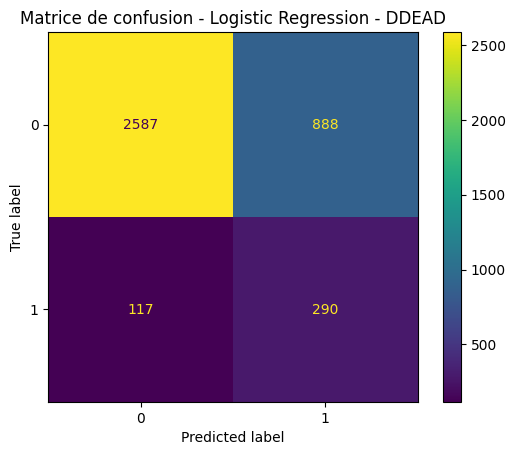

Target : DDEAD
Modèle : Random Forest
Accuracy  : 0.8928
Precision : 0.4211
Recall    : 0.0590
F1-score  : 0.1034
AUC-ROC   : 0.7802

Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      3475
           1       0.42      0.06      0.10       407

    accuracy                           0.89      3882
   macro avg       0.66      0.52      0.52      3882
weighted avg       0.85      0.89      0.85      3882



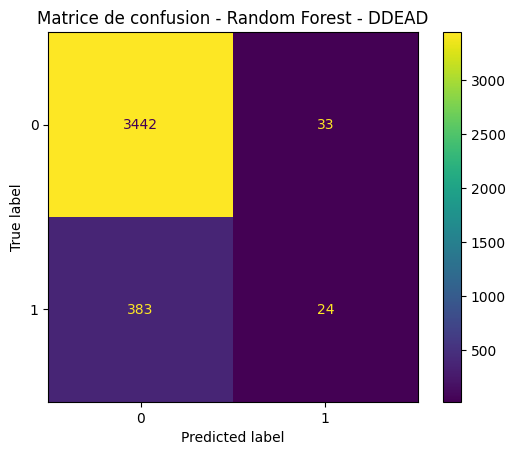

In [8]:

# =========================
# 7. Modélisation sur DDEAD
# =========================

results_ddead = []

for model_name, model in models.items():
    result = evaluate_model(
        model=model,
        X_train=X_train_ddead,
        X_test=X_test_ddead,
        y_train=y_train_ddead,
        y_test=y_test_ddead,
        model_name=model_name,
        target_name="DDEAD"
    )
    results_ddead.append(result)



## Entraînement et évaluation sur `FDEAD`

On répète maintenant la même logique pour la seconde tâche de l’Axe 3 : la prédiction de la **mortalité à 6 mois**.

Cela permet d’obtenir un deuxième tableau de résultats, comparable au premier.


Target : FDEAD
Modèle : Logistic Regression
Accuracy  : 0.7427
Precision : 0.4582
Recall    : 0.7391
F1-score  : 0.5657
AUC-ROC   : 0.8086

Classification Report :
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      2982
           1       0.46      0.74      0.57       874

    accuracy                           0.74      3856
   macro avg       0.68      0.74      0.69      3856
weighted avg       0.81      0.74      0.76      3856



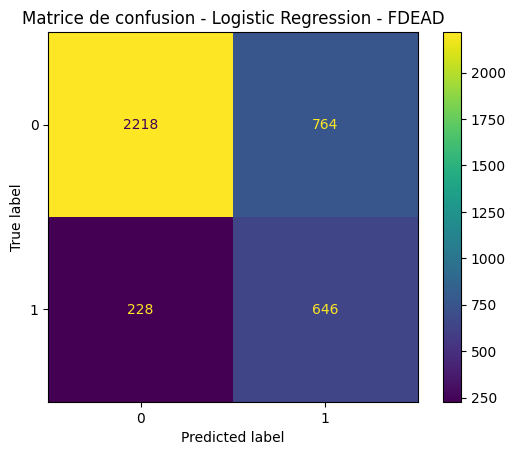

Target : FDEAD
Modèle : Random Forest
Accuracy  : 0.7982
Precision : 0.6048
Recall    : 0.3169
F1-score  : 0.4159
AUC-ROC   : 0.7844

Classification Report :
              precision    recall  f1-score   support

           0       0.82      0.94      0.88      2982
           1       0.60      0.32      0.42       874

    accuracy                           0.80      3856
   macro avg       0.71      0.63      0.65      3856
weighted avg       0.77      0.80      0.77      3856



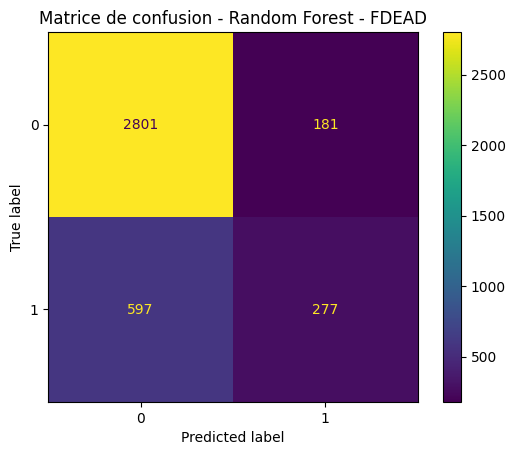

In [9]:

# =========================
# 8. Modélisation sur FDEAD
# =========================

results_fdead = []

for model_name, model in models.items():
    result = evaluate_model(
        model=model,
        X_train=X_train_fdead,
        X_test=X_test_fdead,
        y_train=y_train_fdead,
        y_test=y_test_fdead,
        model_name=model_name,
        target_name="FDEAD"
    )
    results_fdead.append(result)



## Tableau récapitulatif des résultats

Pour faciliter la lecture et la comparaison, on regroupe les métriques calculées dans des DataFrames.

Cela permet de voir rapidement :
- quel modèle performe le mieux ;
- quel modèle offre le meilleur Recall ;
- si les résultats sont équilibrés entre précision et sensibilité.


In [10]:

# =========================
# 9. Résultats récapitulatifs
# =========================

results_df_ddead = pd.DataFrame(results_ddead).sort_values(by="Recall", ascending=False)
results_df_fdead = pd.DataFrame(results_fdead).sort_values(by="Recall", ascending=False)

print("Résultats - DDEAD")
display(results_df_ddead)

print("Résultats - FDEAD")
display(results_df_fdead)


Résultats - DDEAD


,Target,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,DDEAD,Logistic Regression,0.741113,0.246180,0.712531,0.365931,0.801828
1,DDEAD,Random Forest,0.892839,0.421053,0.058968,0.103448,0.780153


Résultats - FDEAD


,Target,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,FDEAD,Logistic Regression,0.742739,0.458156,0.739130,0.565674,0.808593
1,FDEAD,Random Forest,0.798237,0.604803,0.316934,0.415916,0.784380



## Interprétation des résultats

Dans le contexte médical de ce projet, le **Recall** est une métrique centrale.

### Pourquoi ?
Un faux négatif signifie qu’un patient réellement à risque de décès est classé comme non à risque.  
Cliniquement, cette erreur est plus dangereuse qu’un faux positif.

### Comment lire les résultats ?
- un **Recall élevé** est souhaitable ;
- l’**AUC-ROC** permet d’évaluer la capacité générale de discrimination ;
- la **Precision** aide à comprendre le coût en faux positifs ;
- la **Confusion Matrix** permet de visualiser concrètement les erreurs.


In [11]:

# =========================
# 10. Sélection du meilleur modèle
# =========================

best_model_ddead_name = results_df_ddead.iloc[0]["Model"]
best_model_fdead_name = results_df_fdead.iloc[0]["Model"]

print("Meilleur modèle pour DDEAD (selon Recall) :", best_model_ddead_name)
print("Meilleur modèle pour FDEAD (selon Recall) :", best_model_fdead_name)


Meilleur modèle pour DDEAD (selon Recall) : Logistic Regression
Meilleur modèle pour FDEAD (selon Recall) : Logistic Regression



## Réentraînement des meilleurs modèles sur l’ensemble d’entraînement

Pour préparer la sauvegarde, on recrée les modèles correspondant aux meilleurs résultats observés.  
Ici, on conserve la logique la plus simple : **meilleur modèle selon le Recall**.


In [12]:

# =========================
# 11. Réentraînement des meilleurs modèles
# =========================

best_model_ddead = models[best_model_ddead_name]
best_model_fdead = models[best_model_fdead_name]

best_model_ddead.fit(X_train_ddead, y_train_ddead)
best_model_fdead.fit(X_train_fdead, y_train_fdead)

print("Les meilleurs modèles ont été réentraînés avec succès.")


Les meilleurs modèles ont été réentraînés avec succès.



## Sauvegarde des modèles

On sauvegarde maintenant les modèles entraînés dans Google Drive afin de pouvoir les réutiliser plus tard :

- pour l’inférence ;
- pour l’application Streamlit ;
- pour les comparaisons avec la Version 2.


In [14]:

# =========================
# 12. Sauvegarde des modèles
# =========================

import joblib

save_dir = "/content/drive/MyDrive/Stroke_Project_ML/Models/"

joblib.dump(best_model_ddead, save_dir + "best_model_ddead_v1.pkl")
joblib.dump(best_model_fdead, save_dir + "best_model_fdead_v1.pkl")

print("Modèles sauvegardés avec succès.")


Modèles sauvegardés avec succès.



## Conclusion

Les résultats montrent que la régression logistique surpasse le modèle Random Forest pour la prédiction de la mortalité à 14 jours (DDEAD) et à 6 mois (FDEAD).

Bien que le Random Forest présente une accuracy plus élevée, il souffre d’un très faible recall, ce qui le rend inadapté dans un contexte médical où la détection des patients à risque est cruciale.

La régression logistique offre un meilleur compromis, avec un recall élevé (≈ 0.71 pour DDEAD et ≈ 0.74 pour FDEAD) et une AUC-ROC supérieure à 0.80, ce qui indique une bonne capacité de discrimination.

Ces résultats confirment que, pour l’Axe 3, il est préférable de privilégier un modèle maximisant le recall afin de minimiser les faux négatifs.